In [13]:
import pandas as pd
import numpy as np
import pickle
from sklearn.decomposition import PCA


In [14]:
path = "../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"

In [15]:
mrl_isoform = np.load( path + 'mrl_isoform_resolved.npz')

print(mrl_isoform.files)

print("\nArray shapes:")
print(f"X shape: {mrl_isoform['X'].shape}")
print(f"y shape: {mrl_isoform['y'].shape}")
print(f"genes shape: {mrl_isoform['genes'].shape}")

print(f"\nFirst few y values: {mrl_isoform['y'][:10]}")

print(f"\nX dimensions: {mrl_isoform['X'].ndim}")
if mrl_isoform['X'].ndim == 3:
    print(f"X first sample shape: {mrl_isoform['X'][0].shape}")
    print(f"X first sample, first feature vector: {mrl_isoform['X'][0, 0, :5]}")  # First 5 features
elif mrl_isoform['X'].ndim == 2:
    print(f"X first sample (first 10 features): {mrl_isoform['X'][0, :10]}")

['X', 'y', 'genes']

Array shapes:
X shape: (11693, 12288, 6)
y shape: (11693,)
genes shape: (11693,)

First few y values: [5.40141546 3.33709259 5.41937329 5.74227841 5.32184319 5.95879864
 3.3906673  2.96185415 3.62454262 3.8039584 ]

X dimensions: 3
X first sample shape: (12288, 6)
X first sample, first feature vector: [1. 0. 0. 0. 0.]


In [16]:
def create_gene_embedding_dataframe(embeddings, genes, method_name="mrl_pca"):
    """
    Create a DataFrame with gene_ids as index and embeddings as columns
    """
    # Create column names for embedding dimensions
    n_dims = embeddings.shape[1]
    column_names = [f'PCA_{i}' for i in range(n_dims)]
    
    # Create DataFrame
    df = pd.DataFrame(embeddings, columns=column_names)
    df['gene_id'] = genes
    df = df.set_index('gene_id')

    # Keep only the first occurrence of each gene
    df = df[~df.index.duplicated(keep='first')]
    
    return df
    
def isoform_to_gene_embeddings_pca(X, genes, n_components=128):
    """
    Use PCA to create gene embeddings from isoform data
    """
    X_flat = X.reshape(X.shape[0], -1)
    
    pca = PCA(n_components=n_components)
    gene_embeddings = pca.fit_transform(X_flat)
    
    print(f"Explained variance ratio (first 10): {pca.explained_variance_ratio_[:10]}")
    print(f"Total explained variance: {np.sum(pca.explained_variance_ratio_):.3f}")
    
    return gene_embeddings, pca

In [17]:
pca_embeddings, pca_model = isoform_to_gene_embeddings_pca(mrl_isoform['X'], mrl_isoform['genes'], n_components=1024)
print(f"PCA embeddings shape: {pca_embeddings.shape}")

Explained variance ratio (first 10): [0.07037991 0.02956103 0.02884267 0.0200473  0.00938821 0.00695937
 0.00686706 0.00641901 0.0052162  0.00419124]
Total explained variance: 0.547
PCA embeddings shape: (11693, 1024)


In [18]:
total_explained_variance = np.sum(pca_model.explained_variance_ratio_)
print(f"Total explained variance by PCA {total_explained_variance:.2%}")

Total explained variance by PCA 54.74%


In [19]:
pca_embeddings = create_gene_embedding_dataframe(pca_embeddings, mrl_isoform['genes'], method_name="mrl_pca")
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1014,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023
gene_id,,,,,,,,,,,,,,,,,,,,,
DPM1,-10.361529,-8.008942,-4.610142,-1.607383,-1.603568,-2.098625,7.689998,-2.192731,2.336392,4.715554,...,-0.407193,0.730901,-0.359659,0.630838,0.065983,-0.221508,-0.274051,0.027571,-0.664217,0.447146
SCYL3,7.433342,-0.213358,20.708685,10.193992,0.171460,1.669660,1.956169,5.487548,-4.517016,4.052445,...,-0.172451,-0.314922,0.875767,0.579427,-0.206342,-0.401912,-0.187996,0.169953,0.272361,-1.376225
CFH,-4.719111,0.235217,15.849966,5.422871,-5.956711,-4.142274,-3.241006,-1.927898,3.192172,5.278052,...,0.010882,-0.144101,0.632272,0.591330,-0.438692,0.511075,0.315258,0.517418,-0.349261,-0.510832
FUCA2,0.285524,-13.308829,-7.988857,8.813583,-5.129483,-1.180700,5.993691,-2.090514,-1.312564,2.291228,...,-0.412662,0.531203,-0.713775,0.089555,-0.248468,0.544846,-0.381484,-0.187580,0.611391,-0.233674
GCLC,-0.833933,8.637342,-4.698057,7.718352,-5.330405,4.518104,-0.847529,-1.617334,-0.353551,-0.556158,...,-0.038616,0.239177,-0.232737,-0.073581,0.252574,-0.391474,0.586314,-0.574915,-0.643539,-0.956310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PTP4A1,15.378114,5.489214,-2.850180,1.783017,9.694752,4.618853,0.581023,-7.849329,0.445557,1.779173,...,0.039124,0.178337,-0.045222,0.428270,-0.071572,0.033439,0.142374,0.008045,-0.489711,0.051015
NOTCH2NLB,25.368298,-0.191846,9.848917,-14.466546,-5.134555,-1.124350,-3.638568,-11.873979,-1.226618,-3.579755,...,0.730606,-4.047965,1.625974,0.362858,-2.008383,2.131283,1.140633,1.398272,0.692188,0.359375
CHTF8,-11.902716,-0.075104,3.761488,-3.102909,0.091446,-3.052718,-3.424348,-1.653272,1.053344,-0.681357,...,0.374392,0.273468,0.131018,-0.862591,0.175843,-0.110090,-0.005884,-0.263466,-0.071983,-0.370844


In [20]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [21]:
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1014,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023
gene_id,,,,,,,,,,,,,,,,,,,,,
DPM1,-10.361529,-8.008942,-4.610142,-1.607383,-1.603568,-2.098625,7.689998,-2.192731,2.336392,4.715554,...,-0.407193,0.730901,-0.359659,0.630838,0.065983,-0.221508,-0.274051,0.027571,-0.664217,0.447146
SCYL3,7.433342,-0.213358,20.708685,10.193992,0.171460,1.669660,1.956169,5.487548,-4.517016,4.052445,...,-0.172451,-0.314922,0.875767,0.579427,-0.206342,-0.401912,-0.187996,0.169953,0.272361,-1.376225
CFH,-4.719111,0.235217,15.849966,5.422871,-5.956711,-4.142274,-3.241006,-1.927898,3.192172,5.278052,...,0.010882,-0.144101,0.632272,0.591330,-0.438692,0.511075,0.315258,0.517418,-0.349261,-0.510832
FUCA2,0.285524,-13.308829,-7.988857,8.813583,-5.129483,-1.180700,5.993691,-2.090514,-1.312564,2.291228,...,-0.412662,0.531203,-0.713775,0.089555,-0.248468,0.544846,-0.381484,-0.187580,0.611391,-0.233674
GCLC,-0.833933,8.637342,-4.698057,7.718352,-5.330405,4.518104,-0.847529,-1.617334,-0.353551,-0.556158,...,-0.038616,0.239177,-0.232737,-0.073581,0.252574,-0.391474,0.586314,-0.574915,-0.643539,-0.956310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PTP4A1,15.378114,5.489214,-2.850180,1.783017,9.694752,4.618853,0.581023,-7.849329,0.445557,1.779173,...,0.039124,0.178337,-0.045222,0.428270,-0.071572,0.033439,0.142374,0.008045,-0.489711,0.051015
NOTCH2NLB,25.368298,-0.191846,9.848917,-14.466546,-5.134555,-1.124350,-3.638568,-11.873979,-1.226618,-3.579755,...,0.730606,-4.047965,1.625974,0.362858,-2.008383,2.131283,1.140633,1.398272,0.692188,0.359375
CHTF8,-11.902716,-0.075104,3.761488,-3.102909,0.091446,-3.052718,-3.424348,-1.653272,1.053344,-0.681357,...,0.374392,0.273468,0.131018,-0.862591,0.175843,-0.110090,-0.005884,-0.263466,-0.071983,-0.370844


In [22]:
NCG_Known_Genes = emogi_predictions[['Name', "NCG_Known_Cancer_Gene"]]
merged = pca_embeddings.merge(NCG_Known_Genes, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023,NCG_Known_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
DPM1,-10.361529,-8.008942,-4.610142,-1.607383,-1.603568,-2.098625,7.689998,-2.192731,2.336392,4.715554,...,0.730901,-0.359659,0.630838,0.065983,-0.221508,-0.274051,0.027571,-0.664217,0.447146,False
SCYL3,7.433342,-0.213358,20.708685,10.193992,0.171460,1.669660,1.956169,5.487548,-4.517016,4.052445,...,-0.314922,0.875767,0.579427,-0.206342,-0.401912,-0.187996,0.169953,0.272361,-1.376225,False
CFH,-4.719111,0.235217,15.849966,5.422871,-5.956711,-4.142274,-3.241006,-1.927898,3.192172,5.278052,...,-0.144101,0.632272,0.591330,-0.438692,0.511075,0.315258,0.517418,-0.349261,-0.510832,False
FUCA2,0.285524,-13.308829,-7.988857,8.813583,-5.129483,-1.180700,5.993691,-2.090514,-1.312564,2.291228,...,0.531203,-0.713775,0.089555,-0.248468,0.544846,-0.381484,-0.187580,0.611391,-0.233674,False
GCLC,-0.833933,8.637342,-4.698057,7.718352,-5.330405,4.518104,-0.847529,-1.617334,-0.353551,-0.556158,...,0.239177,-0.232737,-0.073581,0.252574,-0.391474,0.586314,-0.574915,-0.643539,-0.956310,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SCO2,-11.021691,-8.526528,-5.202515,-2.475116,-1.106725,-2.811286,7.074593,0.870503,3.028499,-0.628025,...,0.292201,0.095261,-0.030566,-0.533239,0.547688,-0.257532,-0.176064,0.312004,0.089334,False
TBCE,-3.199916,-0.195192,13.523295,6.196819,-5.897826,-0.775914,0.624610,1.177227,2.232309,3.613913,...,-0.140419,0.592972,0.782088,0.087831,-0.447565,0.695985,0.444378,0.015430,-0.574438,False
ABCF2,16.090095,17.135822,-9.145933,4.259971,6.373613,1.688988,-0.188709,2.161776,3.379265,-0.509944,...,-0.181071,-0.849380,-1.719848,-1.097398,-0.774314,-0.335120,-0.072228,0.075477,-1.806782,False


In [23]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    5610
True      331
Name: count, dtype: int64

/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [18:49:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


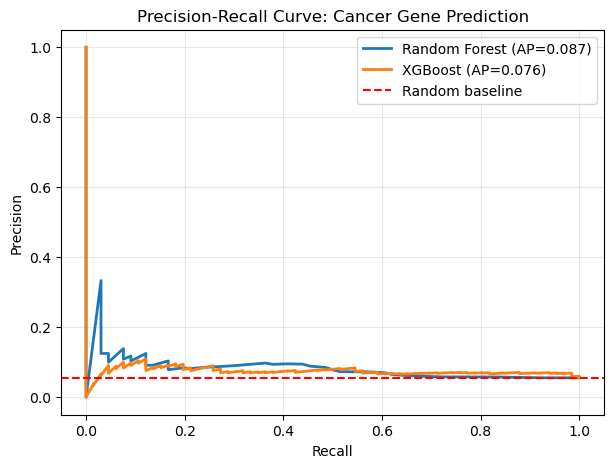

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd

# Add XGBoost
from xgboost import XGBClassifier

# Prepare features and target
X = merged.drop('NCG_Known_Cancer_Gene', axis=1)
y = merged['NCG_Known_Cancer_Gene']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split (80-20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Train Random Forest
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train, y_train)
y_prob_rf = clf_rf.predict_proba(X_test)[:, 1]

# Train XGBoost
clf_xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
clf_xgb.fit(X_train, y_train)
y_prob_xgb = clf_xgb.predict_proba(X_test)[:, 1]

# Precision-recall curves
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
ap_score_rf = average_precision_score(y_test, y_prob_rf)

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
ap_score_xgb = average_precision_score(y_test, y_prob_xgb)

plt.figure(figsize=(7, 5))
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP={ap_score_rf:.3f})', linewidth=2)
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AP={ap_score_xgb:.3f})', linewidth=2)
plt.axhline(y=sum(y_test)/len(y_test), color='red', linestyle='--', label='Random baseline')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Cancer Gene Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()